# Week 6：用舵機把0～6變成看得見的指針

完整備課版（含參考解答）｜2026-10-14

螢幕寫「4」，指針也指在紙盤的4，這是同一份資訊的兩種呈現。
本週先用人工輸入0～6測試指示，不用舵機推門、承重、指向同學或連續旋轉。
Week 7才把這個數字接上遊戲的有效次數。紙指針越輕、越短，越容易看清資料與動作的關係。

### 教學目標

1. 沿圖說明控制訊號、舵機負載供電與共同地的不同路徑。
2. 在電源與端子核准後，分別量測外部電源極性、空載電壓及動作時電壓，正確解讀單位。
3. 把0～6映射到已核准的指令角度區間，區分角度命令與實際位置。
4. 以無負載、輕量紙指針、OLED同步的順序完成受限操作，處理停止、逾時與重啟。
5. 以程式、供電、訊號及機構證據分析指針不動或錯位，避免帶電改線或強推舵機。

### 教學內容

本週建立控制訊號與工作電力分離的概念。學生先核對舵機（servo）、四顆1.5 V AA電池與降壓模組，
理解共地（common ground）如何提供訊號參考，再以受限指令驗證輕量指針的七個位置。
螢幕與指針使用同一個次數變數，學生逐項比較保持位置、停止脈波及切斷電源的不同現象，
透過可追蹤紀錄與單一變因排錯，而不是看到程式印出角度就認定機構已到位。

## 1. 先核對實物，不先把電池裝進去

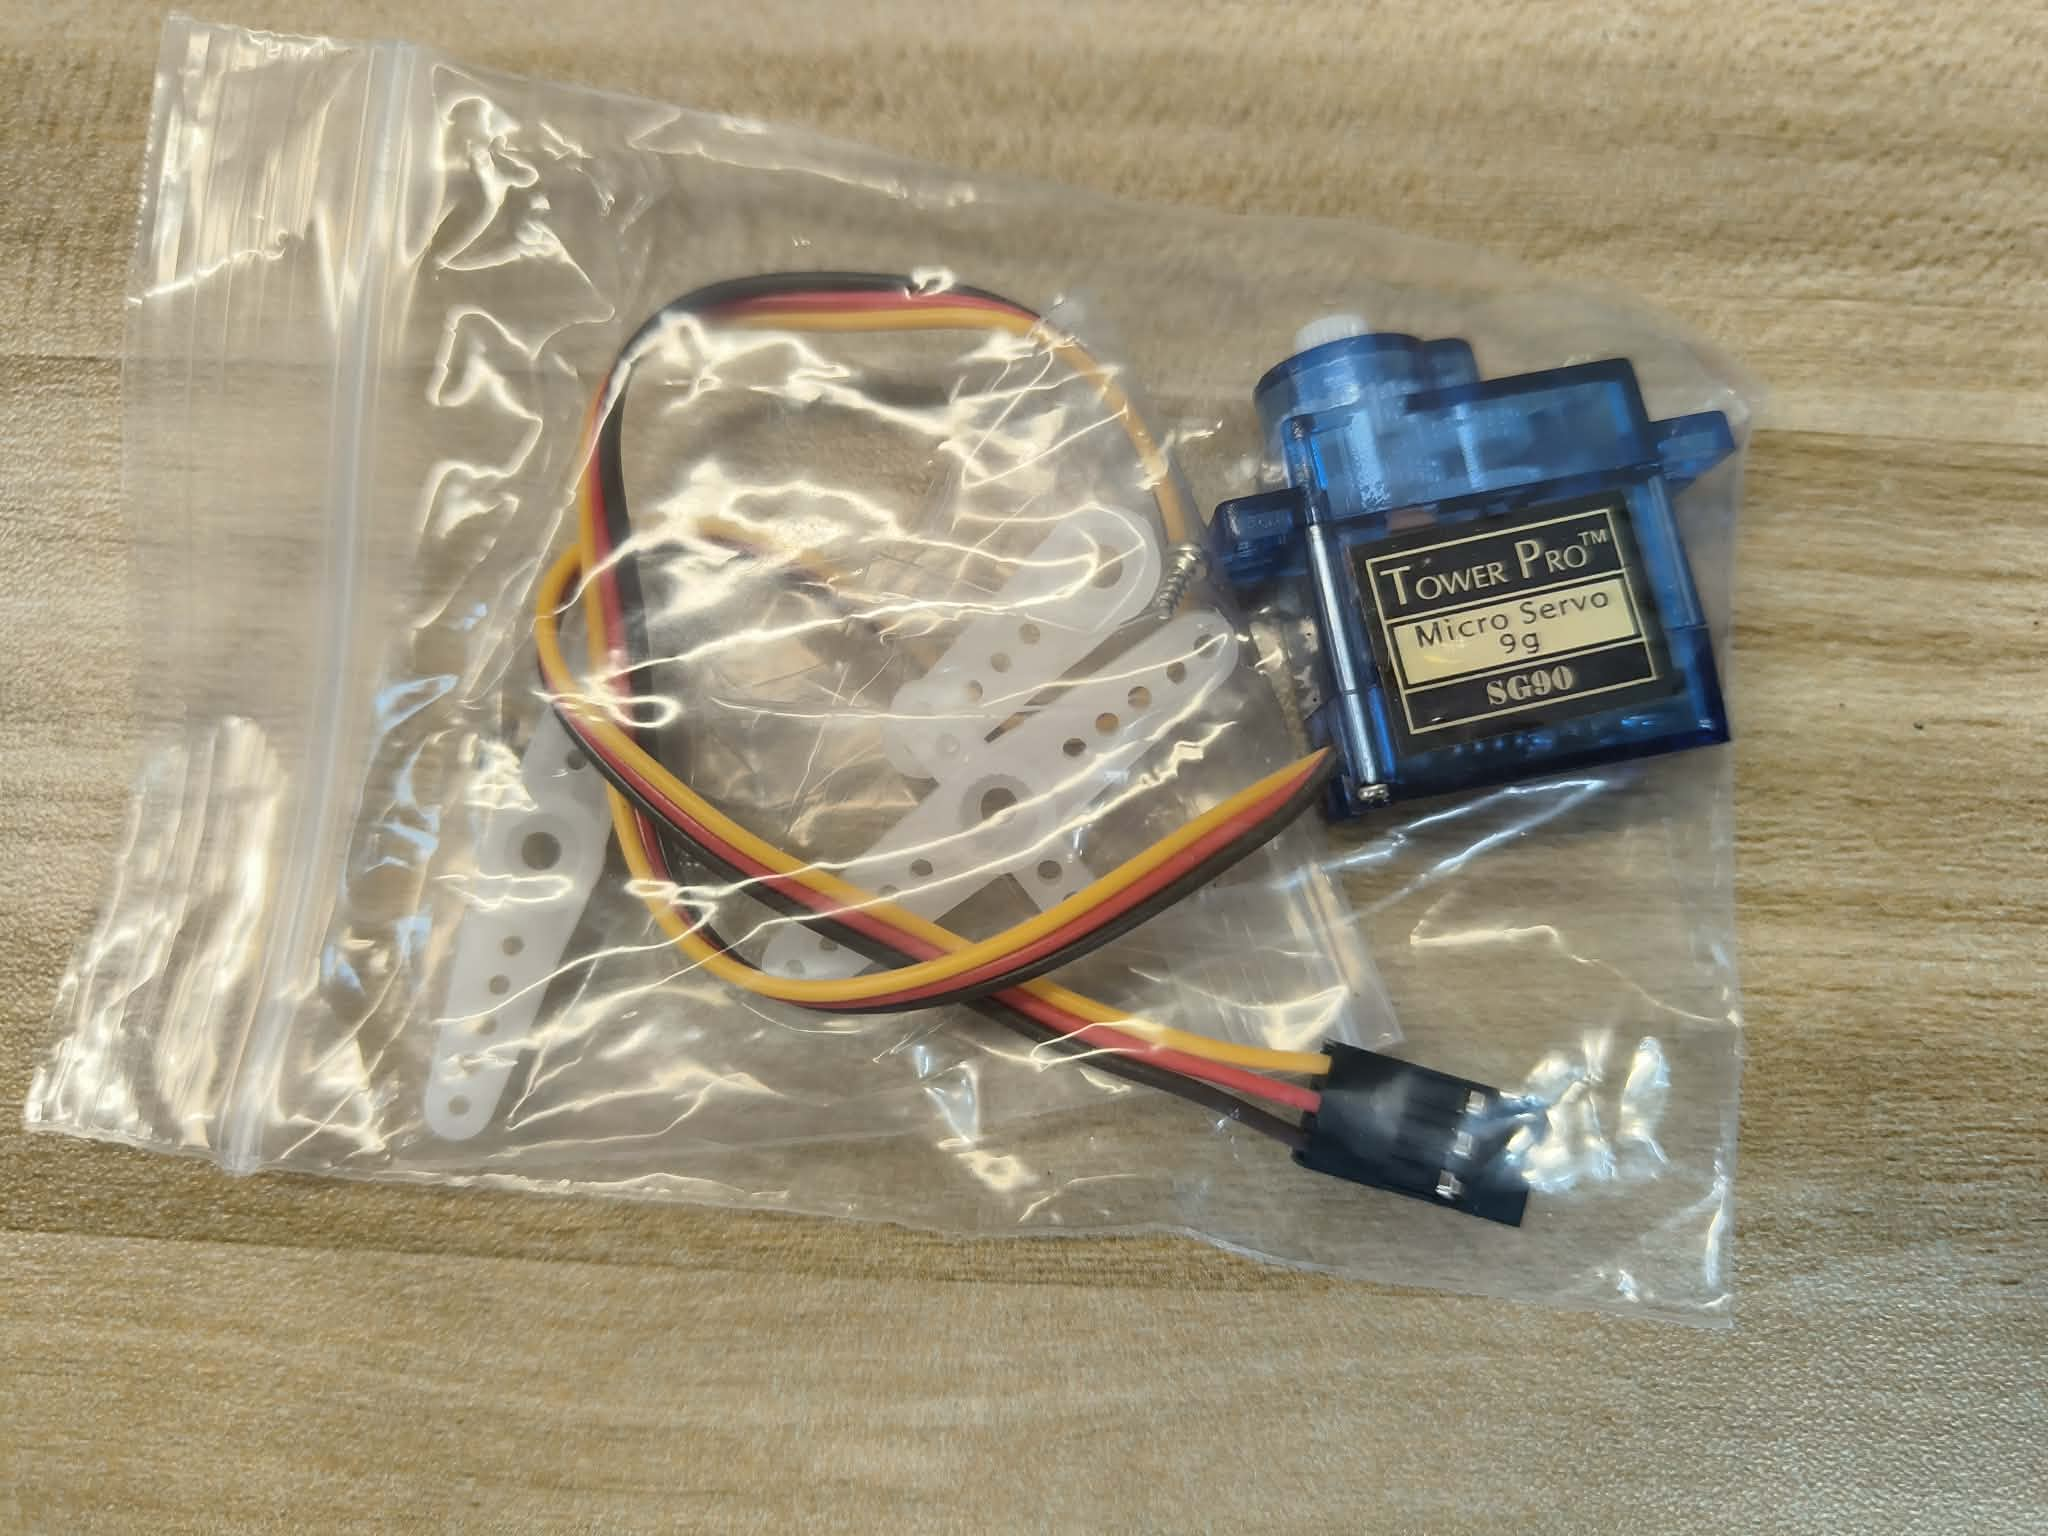

照片可辨識SG90、9g標示、三線接頭與白色舵盤。9g是產品重量級別，不是可承受9公斤，
也不是需要9 V。舵盤（servo horn）裝在輸出軸上，讓指針能固定在轉動部分；
固定本體則用外殼安裝耳或不壓迫外殼的固定方式，不把膠灌入軸、接頭或齒輪。

同樣寫SG90的商品可能有不同版本、來源或旋轉型態。原廠產品頁也不能證明手上這顆與該頁相同。
本課需要定位型舵機，不使用連續旋轉型充當角度指針；不能因商品寫180°就直接要求走滿0～180°。

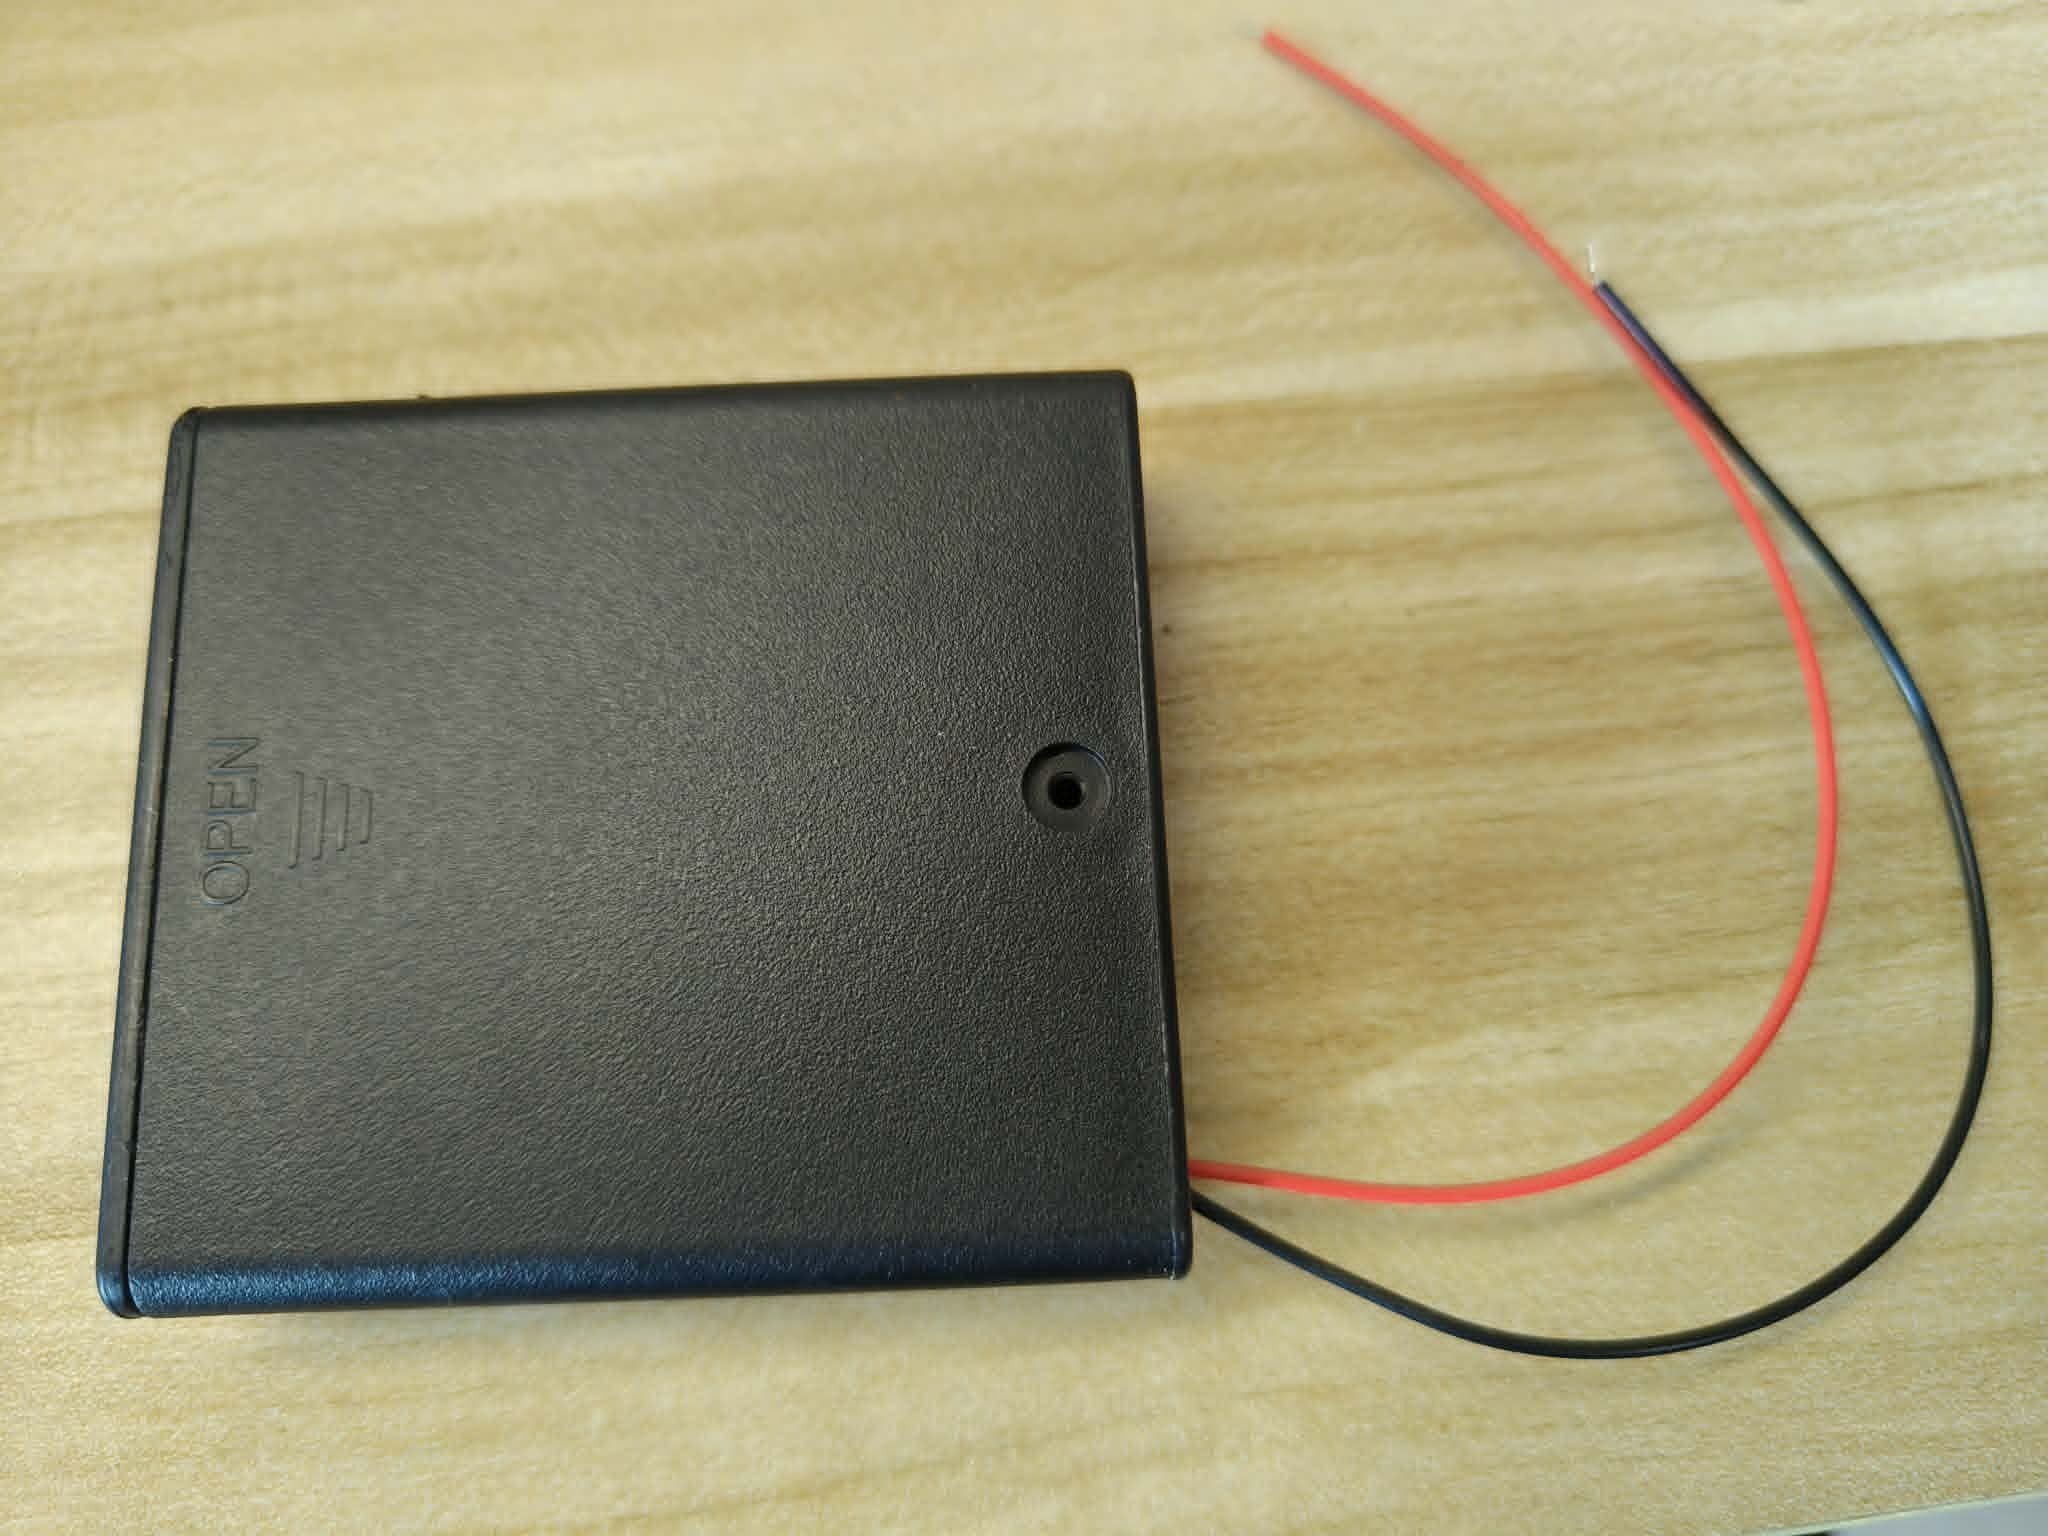

器材：ESP32-S3與USB、核准SG90、四槽帶開關電池盒、四顆1.5 V AA、可調降壓模組及安全端子、麵包板／杜邦線、
一顆已測四腳按鈕作停止鍵、電表、短紙指針、紙刻度與固定底板。最後再接Week 5核准OLED。
RGB、蜂鳴器、KY與DHT先分開收納。電池盒、降壓模組、電池與連接材料可按組共用，
數量與預算見[Week 1採購表](../Week_01_Course_Orientation/week1_main.md#purchase-table)。
一次只供一顆舵機，換接先關電池並拔USB，每人輪流操作與記錄；不新增馬達驅動板。

### 1.1 這些欄位缺一，不進入相應實體操作

| 核准資料 | 要確認什麼 | 為何不能省 |
|---|---|---|
| SG90確切版本 | 定位型、接頭三個功能、供電範圍、控制邏輯相容性 | 不能從線色或9g推電壓／腳序 |
| 電池方案 | AA種類、四顆一致型號／狀態、空載及負載允許範圍、停止值 | 四顆1.5 V與四顆1.2 V並非同樣名目電壓 |
| 降壓模組 | VIN／VOUT極性、調整後輸出、輸入餘量、啟動負載與發熱 | 顯示正常不代表能穩定帶動舵機；不套用晶片最大電流作整板保證 |
| 安全端子 | 型號、導線固定、絕緣、極性、可操作電源開關與容許電流 | 不把裸線鬆塞麵包板或杜邦母頭 |
| 舵機設定 | 頻率、最小／最大脈寬、初始切換行為、小範圍安全角度 | library的數字限制不等於機構安全範圍 |
| 板卡腳位 | 舵機訊號GPIO、STOP GPIO，與SDA／SCL分開 | 不能把電源腳、禁用腳或其他模組GPIO拿來用 |
| 固定與停止 | 無負載驗證、輕指針、沒有碰撞、detach後行為、可安全斷電 | 程式沒有感測舵機卡住、電壓或實際角度 |

查核入口：[硬體狀態](../docs/hardware/hardware_state.md)。這些項目目前仍有實機待驗欄位，
未核准前保持電池取出、profile為false／-1，只做圖解、計算與編譯。
不能把「想使用四顆AA」當成「任何四顆AA都已核准」。若現有轉接或電池方案不合適，
先由教師確認規格及採購影響，不臨時叫學生購買未列材料或自行加工裸線。


<!-- hardware-gallery:start -->
<a id="equipment-photos"></a>

### 本週器材外觀

SG90指出次數，按鈕作STOP，最後核對OLED顯示。另備筆電、USB資料線、四顆1.5 V AA與牢固絕緣的連接材料；電池盒經降壓模組供舵機，供電組可按組共用，供電核准前不接舵機。

照片下方標示拍攝角度與來源。先辨認零件，再依本週器材表與接線步驟操作；照片本身不是接線指令，也不表示已完成電氣驗證。

[ESP32-S3 開發板](#equipment-esp32s3) · [400 孔麵包板](#equipment-breadboard400) · [杜邦線](#equipment-jumperwire) · [萬用電表](#equipment-a830l) · [SG90 舵機](#equipment-sg90) · [四槽 AA 帶開關電池盒](#equipment-batteryholder4aa) · [四腳輕觸按鈕](#equipment-pushbutton) · [有機發光二極體顯示模組](#equipment-oled) · [帶數字顯示的降壓模組](#equipment-buckconverter)

<a id="equipment-esp32s3"></a>

#### ESP32-S3 開發板（Development Board）

照片中的板卡為 YD-ESP32-S3 Type-A V1.5，搭載 N16R8 模組。正反面白底圖是既有後製展示圖；小字與腳位須核對本人實物及本週接線資料。

| 實物後製展示圖：正面：模組、按鈕與 USB 接頭 | 實物後製展示圖：背面：板身與排針 |
| --- | --- |
| ![ESP32-S3 開發板（Development Board）；實物後製展示圖；正面：模組、按鈕與 USB 接頭](../docs/images/hardware/actual/ESP32S3_1.png) | ![ESP32-S3 開發板（Development Board）；實物後製展示圖；背面：板身與排針](../docs/images/hardware/actual/ESP32S3_2.png) |

其他留存角度：[麵包板對孔紀錄；不是建議的實驗安裝方式，右側接線空間不足](../docs/images/hardware/actual/ESP32S3_3.jpg)。

<a id="equipment-breadboard400"></a>

#### 400 孔麵包板（Breadboard）

辨認中央溝槽、a～j 字母與列號。外觀照片不表示所有孔都相通，連通關係依本週圖解與斷電量測確認。

| 實物照片：俯視：中央溝槽、五孔組與側邊電源軌 |
| --- |
| ![400 孔麵包板（Breadboard）；實物照片；俯視：中央溝槽、五孔組與側邊電源軌](../docs/images/hardware/actual/Breadboard400_1.jpg) |

<a id="equipment-jumperwire"></a>

#### 杜邦線（Jumper Wire）

露出金屬針的是公頭（Male），有插孔的是母頭（Female）；線色不會自行決定電壓或功能。所需接頭種類依當週器材表，不是每週都用完三種。商品參考卡上的數量與金額是歷史資料，不是學生應買數量或目前售價。

| 實物照片：成排導線與接頭全貌 | 蝦皮商品參考：公對公：兩端皆為金屬針 |
| --- | --- |
| ![杜邦線（Jumper Wire）；實物照片；成排導線與接頭全貌](../docs/images/hardware/actual/JumperWire_1.jpg) | ![杜邦線（Jumper Wire）；蝦皮商品參考；公對公：兩端皆為金屬針](../docs/images/hardware/product-cards/JumperWire_MM_1.png) |

| 蝦皮商品參考：公對母：金屬針與插孔各一端 | 蝦皮商品參考：母對母：兩端皆為插孔 |
| --- | --- |
| ![杜邦線（Jumper Wire）；蝦皮商品參考；公對母：金屬針與插孔各一端](../docs/images/hardware/product-cards/JumperWire_MF_1.png) | ![杜邦線（Jumper Wire）；蝦皮商品參考；母對母：兩端皆為插孔](../docs/images/hardware/product-cards/JumperWire_FF_1.png) |

<a id="equipment-a830l"></a>

#### 萬用電表（Digital Multimeter）

此照片為 A830L 示範表。學生的表可能不同；旋鈕刻度、插孔及畫面單位以自己的電表為準，不能只照照片轉到相同方向。

| 實物照片：正面：顯示器、旋鈕與表筆插孔 |
| --- |
| ![萬用電表（Digital Multimeter）；實物照片；正面：顯示器、旋鈕與表筆插孔](../docs/images/hardware/actual/A830L_1.jpg) |

<a id="equipment-sg90"></a>

#### SG90 舵機（Servo Motor）

三線插頭、舵機本體與白色舵盤一起辨認。照片中的品牌與型號標籤不證明真偽、安全行程或供電能力；不得由 GPIO 或 3V3 供應馬達電力。

| 實物照片：拆袋全貌：標籤、三線插頭與附件 | 實物照片：包裝內的標籤、插頭與舵盤 |
| --- | --- |
| ![SG90 舵機（Servo Motor）；實物照片；拆袋全貌：標籤、三線插頭與附件](../docs/images/hardware/actual/SG90_1.jpg) | ![SG90 舵機（Servo Motor）；實物照片；包裝內的標籤、插頭與舵盤](../docs/images/hardware/actual/SG90_2.jpg) |

| 實物照片：另一包裝角度 |
| --- |
| ![SG90 舵機（Servo Motor）；實物照片；另一包裝角度](../docs/images/hardware/actual/SG90_3.jpg) |

<a id="equipment-batteryholder4aa"></a>

#### 四槽 AA 帶開關電池盒（Battery Holder）

照片未展示盒內配置；使用時須確認為四槽串聯。Week 6、7使用四顆標稱1.5 V AA，經降壓模組供舵機；電池盒、降壓模組、電池與可靠絕緣連接材料可按組共用，一次只供一顆舵機。極性與負載電壓仍須量測。

| 實物照片：外殼、ON／OFF 開關與紅黑裸線 | 實物照片：另一盒蓋與導線角度 |
| --- | --- |
| ![四槽 AA 帶開關電池盒（Battery Holder）；實物照片；外殼、ON／OFF 開關與紅黑裸線](../docs/images/hardware/actual/BatteryHolder4AA_1.jpg) | ![四槽 AA 帶開關電池盒（Battery Holder）；實物照片；另一盒蓋與導線角度](../docs/images/hardware/actual/BatteryHolder4AA_2.jpg) |

<a id="equipment-pushbutton"></a>

#### 四腳輕觸按鈕（Tactile Pushbutton）

上方黑色部分是按壓位置，四支金屬腳用來連接電路。照片不能單獨證明哪一對腳常通；先斷電，依 Week 2 的方法辨認。

| 實物照片：俯視：按鍵與金屬上蓋 | 實物照片：側面：四支接腳 |
| --- | --- |
| ![四腳輕觸按鈕（Tactile Pushbutton）；實物照片；俯視：按鍵與金屬上蓋](../docs/images/hardware/actual/Pushbutton_1.jpg) | ![四腳輕觸按鈕（Tactile Pushbutton）；實物照片；側面：四支接腳](../docs/images/hardware/actual/Pushbutton_2.jpg) |

其他留存角度：[歷史接線紀錄：同一組常通接點的量測，不是按下才導通的接法答案](../docs/images/hardware/actual/Pushbutton_3.jpg)。

<a id="equipment-oled"></a>

#### 有機發光二極體顯示模組（OLED Display）

實物正面可見 GND／VDD／SCK／SDA，背面標示 MN096-12864-4G V1.0。BOARD-T01 已有 SSD1315 建構子顯示成功的回報，不等於晶片型號或整批電氣驗證。學生選購規格仍以 Week 1 採購表為準。

| 實物照片：正面：螢幕與四個功能標示 | 實物照片：背面：板號與垂直於電路板的排針 |
| --- | --- |
| ![有機發光二極體顯示模組（OLED Display）；實物照片；正面：螢幕與四個功能標示](../docs/images/hardware/actual/OLED_1.jpg) | ![有機發光二極體顯示模組（OLED Display）；實物照片；背面：板號與垂直於電路板的排針](../docs/images/hardware/actual/OLED_2.jpg) |

| 蝦皮商品參考：OLED 在倒數第三列；其他商品與數量不是學生採購要求 |
| --- |
| ![有機發光二極體顯示模組（OLED Display）；蝦皮商品參考；OLED 在倒數第三列；其他商品與數量不是學生採購要求](../docs/images/hardware/orders/shopee-aroundtw-02-drivers-servos-sensors-displays.png) |

<a id="equipment-buckconverter"></a>

#### 帶數字顯示的降壓模組（Buck Converter）

可調降壓模組用於Week 6、7舵機供電，可按組共用。訂單稱LM2596S，實物可見V591與疑似LM2596S ADJ字樣；已有空載調整紀錄，整板負載能力仍待確認。數字顯示器不是OLED，IN與OUT須分清。

| 實物照片：電池接 VIN、輸出未接負載；IN 指示燈亮、顯示 6.47 | 實物照片：元件面、螺絲端子與數字顯示 |
| --- | --- |
| ![帶數字顯示的降壓模組（Buck Converter）；實物照片；電池接 VIN、輸出未接負載；IN 指示燈亮、顯示 6.47](../docs/images/hardware/actual/BuckConverter_3.jpg) | ![帶數字顯示的降壓模組（Buck Converter）；實物照片；元件面、螺絲端子與數字顯示](../docs/images/hardware/actual/BuckConverter_1.jpg) |

| 實物照片：焊接面 |
| --- |
| ![帶數字顯示的降壓模組（Buck Converter）；實物照片；焊接面](../docs/images/hardware/actual/BuckConverter_2.jpg) |

<!-- hardware-gallery:end -->


## 2. 為什麼GPIO不直接供電給舵機？

### 2.1 把訊息與力氣分開想

可以把GPIO訊號想成「指向第4格」的指示，把外部電源想成提供轉動所需能量。
這個類比只幫助分工；真實電路中訊號仍是相對GND的電壓變化，
舵機內部電路讀取脈波後控制內部馬達，電池經V+／GND供應工作電流。
GPIO不是無限電流的電源，不能把SG90的V+接到GPIO或ESP32的3V3。

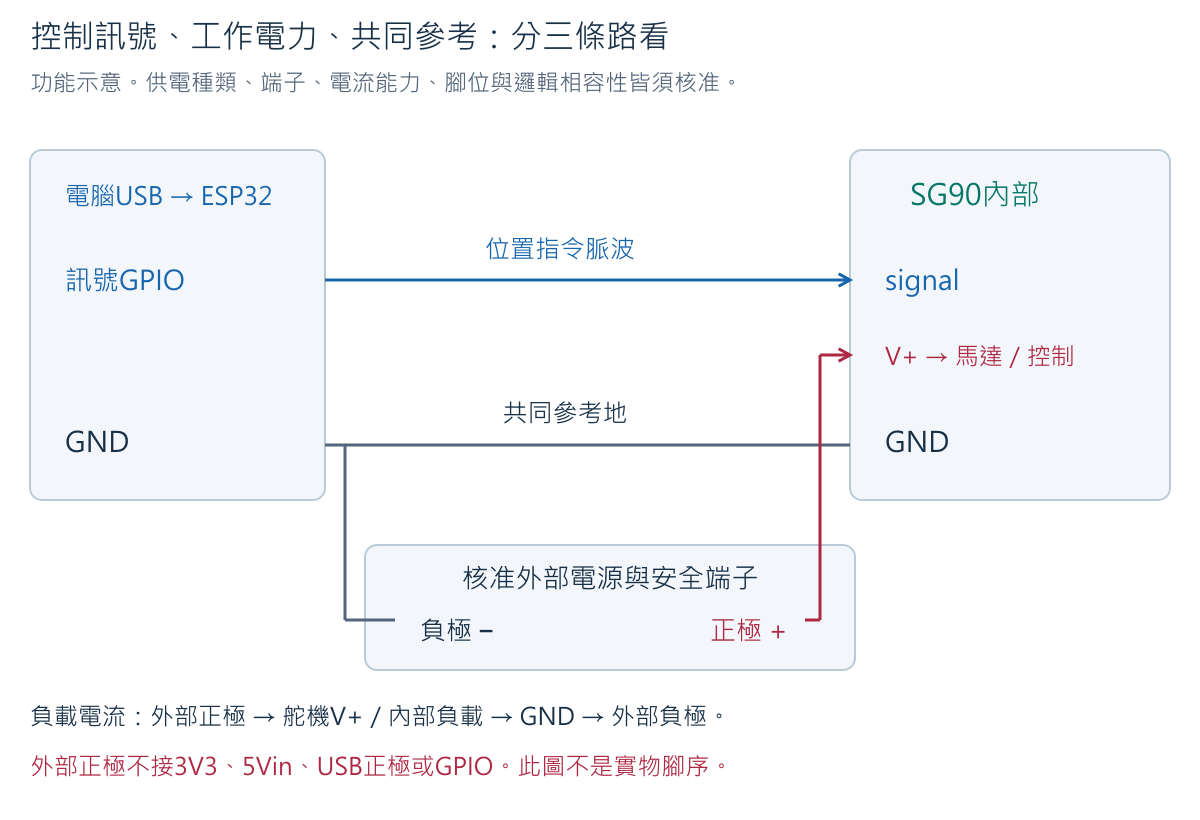

沿圖追兩個回路：

1. 板卡由電腦USB供電，板上電源電路讓ESP32工作；本課不改焊IN-OUT。
2. 圖中的「外部電源」是電池盒經降壓模組後的輸出：VOUT+→安全端子→SG90 V+→舵機內部負載→SG90 GND→VOUT−。電池盒正負只接VIN+／VIN−，不繞過降壓模組。
3. 另有ESP32訊號GPIO→SG90 signal，SG90以自己的GND判讀它的HIGH／LOW。
   外部負極、SG90 GND、ESP32 GND共接，讓兩端的訊號基準一致。

第3條不是把兩個電源正極接在一起，也不表示馬達負載電流應走細長的ESP32訊號線。
舵機供電正負路徑使用核准可承受負載的端子與線材；共地連線提供參考。
外部正極不得接3V3、5Vin、USB VBUS或任何GPIO。`5Vin`在本片YD板的既有驗證中是外部輸入，
不是已確認能供舵機的USB 5 V輸出。

### 2.2 又出現GND：不是多一顆電池

Week 3用「紅表筆電壓−黑表筆電壓」理解量測。
同理，舵機看到的是signal相對於它自己GND的電壓。假設ESP32送出相對板上GND的3.3 V，
若兩端地沒有共同基準，就不能直接說舵機看到同樣的3.3 V。
共地不是讓地「產生負電」，而是把指定參考點連在一起。

**練習**：有人說「我接了signal，舵機自己的電池也有負極，所以不用共地」。哪一段缺了？

**預期答案**：缺少ESP32與舵機訊號準位的共同參考。電池在舵機內部能供電，
不代表來自另一塊板子的訊號已有正確參考；先斷開所有電源，再依核准圖補查共同地。
不可用帶電碰線、拔地或把兩個正極短接來展示錯誤。

## 3. 電表要量什麼：空載與負載不是兩種電壓單位

空載（no load）是尚未供應舵機工作電流的狀況；負載（under load）是舵機接上並動作的狀況。
兩者的單位都為伏特（V），差別是當時電源是否正在供應負載。
電池、導線與接點不是理想無阻力，動作電流增加時，端電壓可能下降。

用假設數值示範：空載5.0 V，動作4.4 V，差0.6 V。這只說觀察到壓降，
是否低於允許值必須對照核准電源／舵機profile，不能憑「有4點多」就說安全。
也不能只憑壓降算出舵機電流，因為沒有已知的完整供電路徑電阻與同步資料。

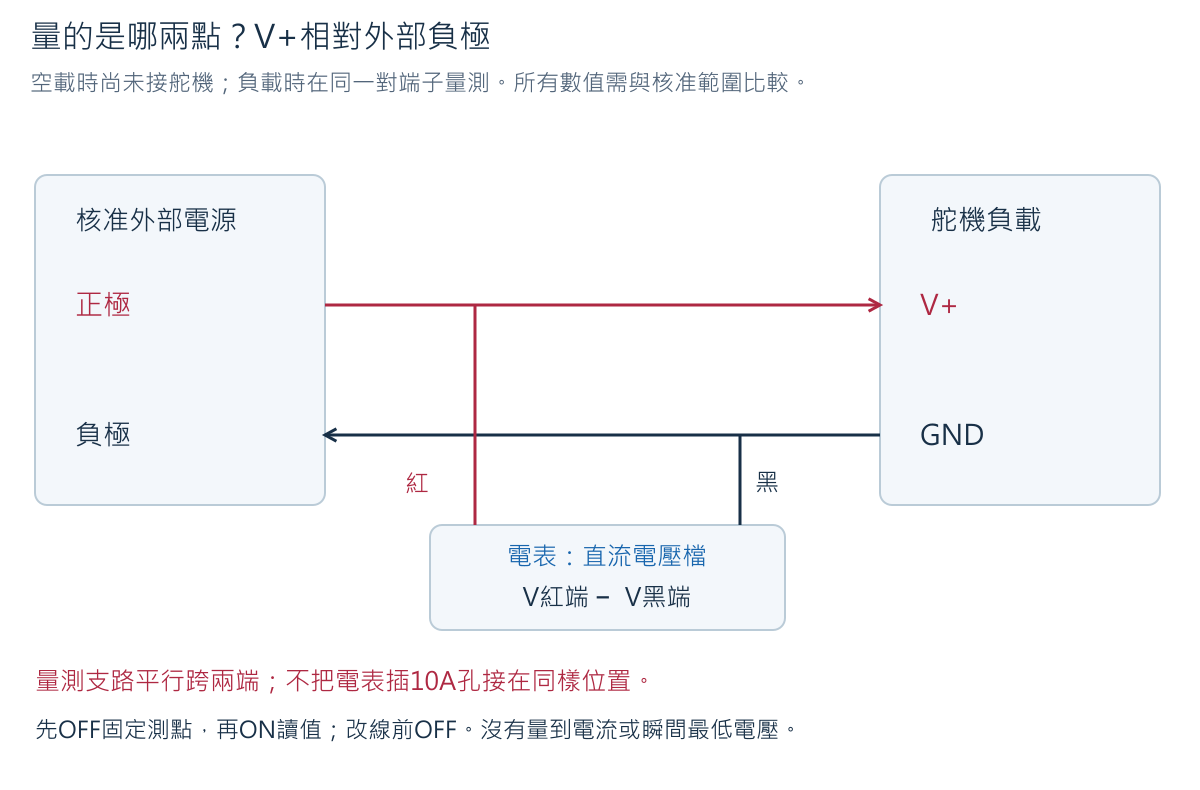

### 3.1 空載量測：先不用舵機

1. 舵機與ESP32都不接電池。確認安全端子、電池種類及量測範圍已核准後才裝電池，開關仍OFF。
2. 黑表筆插COM，紅插VΩmA；旋鈕轉直流電壓。A830L用直流20 V檔，不是Ω、通斷或10A。
3. 開關OFF時先把黑量測端固定在外部負極測點、紅固定在外部正極測點；
   用核准的安全測試端，不拿兩根裸線在手中互相靠近。若一人無法固定，請同組協助。
4. 確認沒有金屬短接後切ON，讀數連正負號與單位記錄；立即OFF再移開表筆。
5. 與profile比較。未落在允許範圍、反號或不穩，保持OFF，不接舵機。

表上−5.0 V的可能原因是紅黑量測方向反了，但也可能電源極性標示／接線有問題。
先OFF核對實際端子，不只在筆記中去掉負號。電表測的是紅端−黑端，不會替你自動確認插頭正負。
電池關閉後再做必要的斷電通斷，不能在帶電狀態轉Ω檔。

### 3.1A 四顆AA為什麼量到6.6 V？

AA是電池尺寸，不是固定電壓。標稱值（nominal value）是產品標示的代表值，
實際端電壓還會隨種類、狀態與負載變化。四顆標稱1.5 V串聯的名目合計是6 V，
不保證電表只能顯示6.00；四顆標稱1.2 V鎳氫電池的名目合計才是4.8 V。
同一盒不得混用不同種類、新舊或不同充電狀態的電池。

2026-09-07教師實際使用四顆1.5 V AA，電表回報6.6 V，並非原先規劃的1.2 V鎳氫組。
不能把它直接當作已核准SG90電源；即使某版本文件允許到6 V，6.6 V仍超過6 V。
[TowerPro產品頁](https://towerpro.com.tw/product/sg90-7/)列出的工作電壓資料須配合確切版本核對，
不是靠「SG90」三個字就保證所有同名品相同。

課程已改採**四顆1.5 V AA＋可調降壓模組**，取代原鎳氫方案。
以下保留實際讀值作判讀案例；採購方案已確定，舵機帶載能力仍待實機驗證。

### 3.1B 降壓模組的IN、OUT與電表讀數

第3.1節的空載檢查分兩段：先量電池盒輸出，再將電池OFF，以VIN接電池、VOUT保持未接舵機。
核對極性與固定後才ON；按下列說明辨認OUT並調整，再以電表跨VOUT+／VOUT−量測。
後續舵機使用的是VOUT，不是電池盒原電壓。未有確切舵機允許範圍與停止值時不進入帶載測試。

降壓模組（buck converter）把較高的輸入電壓轉成較低的輸出電壓。
它不是電池、不是OLED，也不因顯示數字就保證能帶動舵機。
[TI LM2596資料](https://www.ti.com/product/LM2596)說明降壓原理與晶片條件；
晶片標示的能力不能直接當作這片市售載板、端子、導線與電池的整體負載能力。

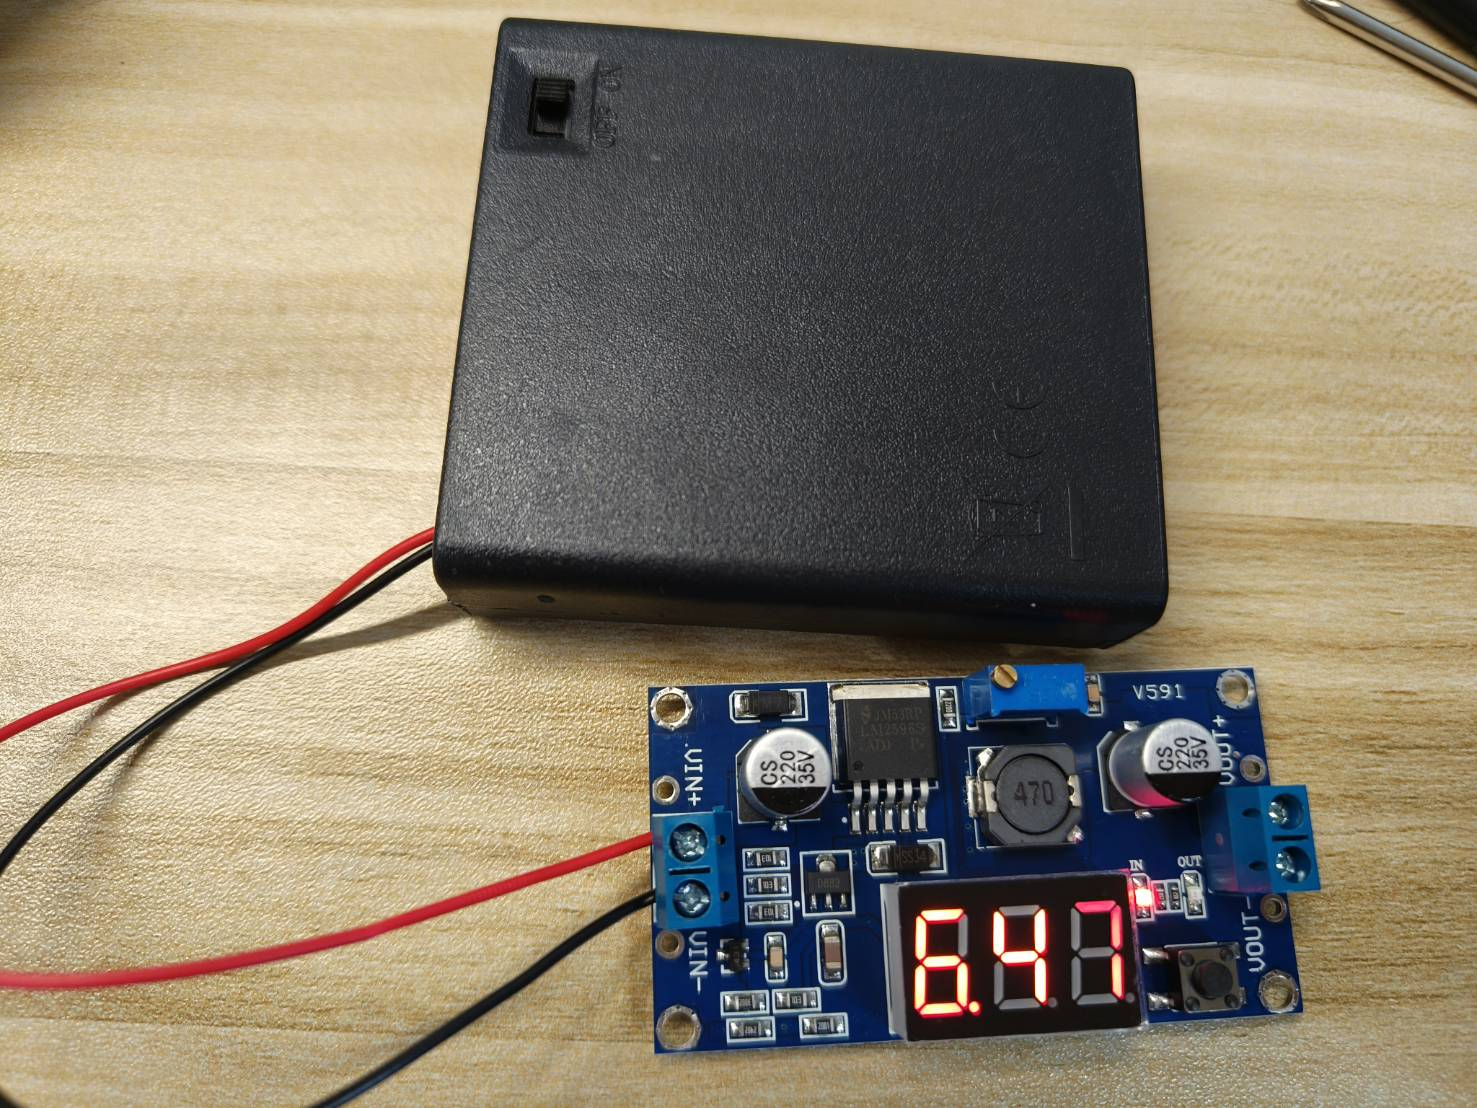

| 標示或部件 | 此處作用 | 容易誤讀的地方 |
|---|---|---|
| VIN+、VIN− | 接電池正、負，提供模組輸入 | 不是舵機輸出端 |
| VOUT+、VOUT− | 調整後的正、負輸出 | 不把VOUT+接ESP32的3V3或5Vin |
| IN／OUT指示燈 | 表示數字顯示器目前在看哪一側 | IN顯示6.47，不是輸出已調成6.47 |
| 藍色可調電阻上的螺絲 | 調整輸出設定 | 不是端子固定螺絲；轉一圈不代表固定改1 V |

照片中IN指示燈亮，顯示6.47；切換OUT後回報6.07。
調整時先確認看的是OUT，再小幅調整並看趨勢；這片實物後續回報逆時針使輸出降低。
其他板不保證同方向，不能盲轉很多圈或硬轉到止點。量測與調整期間不接舵機，
接線或重新固定表筆先OFF；帶電只操作絕緣工具的調整部位，避免碰到相鄰金屬造成短路。
輸入太接近目標輸出時，降壓電路可能沒有足夠調節餘量，轉螺絲不一定能解決。

本次最後記錄為：模組OUT顯示**4.85 V**，電表跨VOUT+／VOUT−回報**4.76 V**。
兩者差0.09 V，不必為了畫面完全一樣而反覆調整；但它們是**兩個讀值**，
不能自行選一個當真值，也不能當成舵機負載時的測量。電表、顯示器未與標準校準，
4.76 V亦略低於4.8 V參考值，因此此處只保存空載進度，不宣告供電核准。

**判讀練習：** 沒接舵機時顯示4.85 V，可以說「動作時一定也有4.85 V」嗎？

**預期答案：** 不行。接入舵機後的電流需求、電池內阻、接點及調節餘量都可能使電壓下降；
慢速電表也可能看不到短暫最低值。下一步先斷電確認接線與固定，再依受限測試核對供電，
不是增加電壓來補猜測的壓降。舵機尚未接通與測試的部分，詳見
[BOARD-T01交接紀錄](../docs/lab_notes/2026-09-07-week7-bringup.md)。

### 3.2 動作時量測：只有後面無負載舵機基本測試通過才做

電表維持相同兩個供電測點與直流檔，平行接在舵機V+與GND。
先OFF固定表筆，再依第7節上電與動作流程量測，保存命令、觀察電壓及現象。
不要故意卡住舵機、使用弱電池或加大負載來製造低壓。
萬用電表刷新慢，讀到的最低值不一定是瞬間最低電壓；不能據此證明完全沒有短脈衝壓降。

**練習**：動作時電表顯示4.8 V，這代表4.8 A嗎？

**預期答案**：不是。V是兩測點的電位差，A才是電流。
本週沒有做電流檔串接量測，不能把電壓數字當電流，也不能換10A孔再跨正負極；那可能造成短路。


## 4. 次數、角度與脈寬是三種不同的數字

### 4.1 0～6不是0～6度

映射（mapping）是把一個範圍的數字對應到另一個範圍。
假設**已核准的指令區間**為30～150度，想放七個數字0～6，
它們之間有6個間隔，因此每格(150−30)÷6=20度。

```text
angle_command = 30 + count × 20
count=0 → 30；count=3 → 90；count=4 → 110；count=6 → 150
```

30與150只是計算示例，不是本片舵機的上電參數，也不保證它有精確相同的實際角度。
程式使用`ZERO_ANGLE`與`SIX_ANGLE`的核准值。若兩者差不是6的整數倍，
整數除法會造成小幅取整；紙盤刻度應對照真正位置，不能用運算結果假造量角器實測。

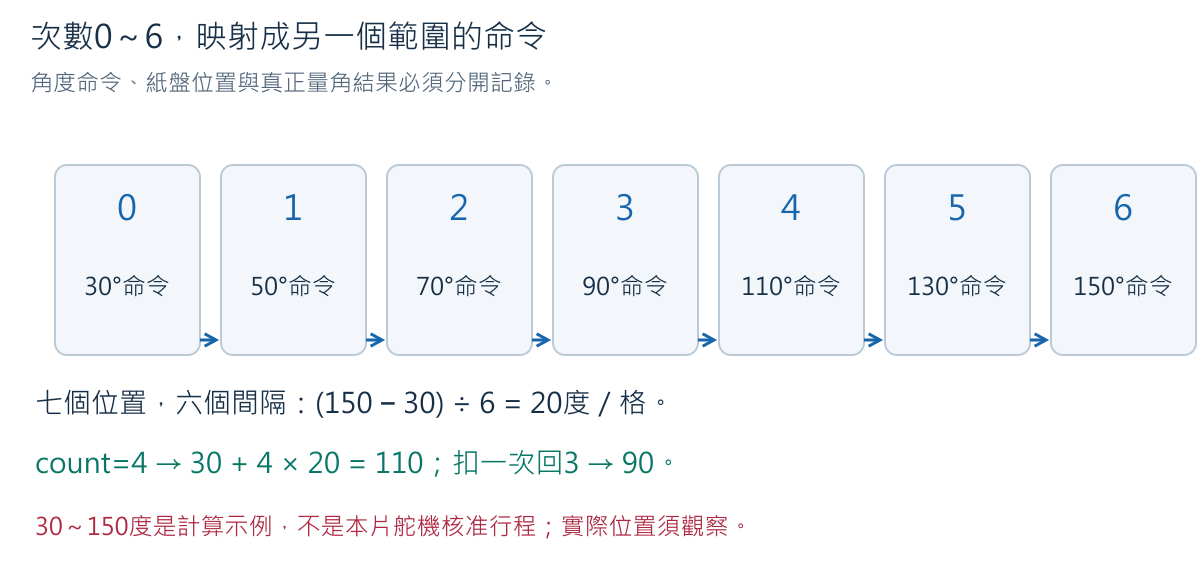

### 4.2 控制訊號不是「一直輸出某個電壓」

脈波（pulse）是一段高、一段低的訊號。脈寬（pulse width）是高的那一段維持多久，
單位微秒（µs）；1000 µs=1 ms，1000 ms=1 s。
例如教學圖畫週期20 ms、其中高1.5 ms，其餘低18.5 ms，每秒重複50次，即50 Hz。
這是時間圖示例，不是所有舵機的固定核准設定。

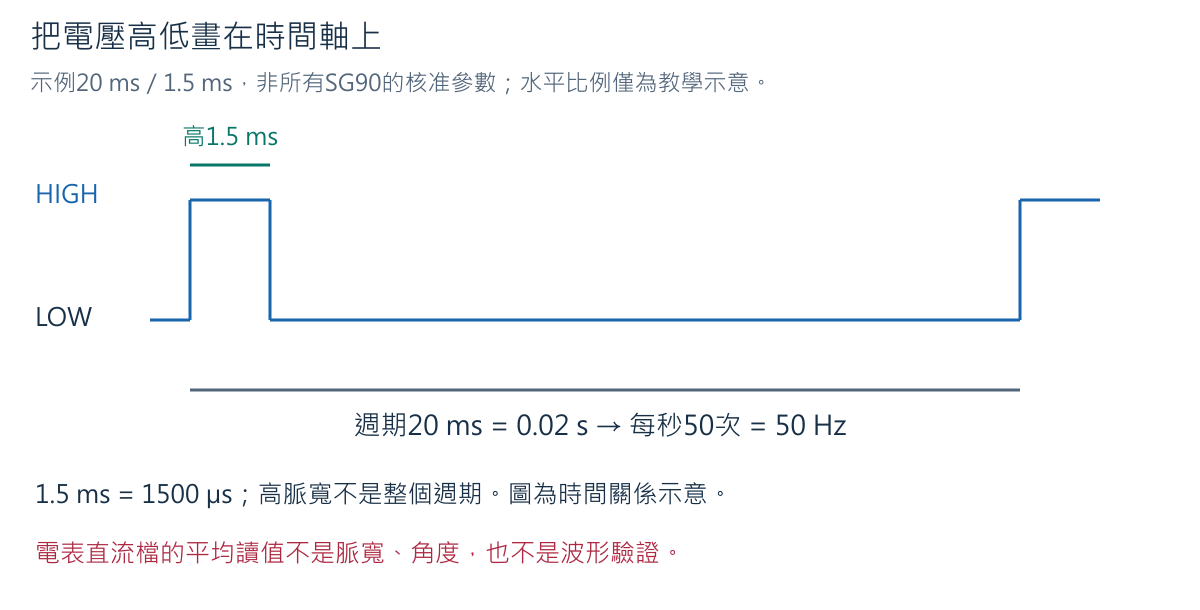

ESP32Servo把`write(angle)`的角度命令依attach指定的脈寬端點轉成控制脈波。
`attach()`啟動控制通道，`write()`指定目標，`detach()`停止該通道的控制脈波。
library的`read()`主要回報曾寫入的命令換算，不是從一般三線SG90量到的真實角度。
本課不把這個值叫角度感測回饋（feedback）。

本次基準library為ESP32Servo 3.2.1。其預設或程式允許的500～2500 µs邊界，
只是library範圍，不是這顆舵機安全行程。必須有較合適的核准脈寬與安全角度，
也要確認初始化、attach及重啟的短暫行為。未通過前不加指針、更不接負載機構。

**練習**：Serial寫count=4、angle_command=110，可以在報告寫「實測110度」嗎？

**預期答案**：不行。只知道程式送出110的命令；還要觀察指針位置、量測方法與誤差。
若沒有角度回傳，輸出`position_measured=false`是誠實標示，不是程式失敗。


## 5. 斷電接線：每條線都說得出目的

所有前提核准後，USB拔除、電池盒OFF並取出至少一顆電池。
本週STOP使用已驗證的四腳按鈕，只選原本不同電氣組的兩端；
不是看左右猜哪兩腳。先獨立確認放開不通、按下通，避免把內部固定相通的一對當開關。

| 功能 | 來源端 | 目的端 | 注意事項 |
|---|---|---|---|
| 降壓輸入正極 | 電池盒正極 | VIN+螺絲端子 | 斷電固定，不接舵機V+ |
| 降壓輸入負極 | 電池盒負極 | VIN−螺絲端子 | 不與正極短接 |
| 舵機工作正極 | 降壓模組VOUT+安全端子 | SG90核准V+ | 不進ESP32或低功率3V3列 |
| 舵機工作負極 | 降壓模組VOUT−安全端子 | SG90核准GND | 負載回流用核准電流路徑 |
| 共同參考 | ESP32 GND→a3 | 外部負極的共地端子 | 和舵機GND同一參考；不是相接兩個正極 |
| 指令 | PIN_SERVO核准GPIO | SG90核准signal | 舵機接頭若母頭，使用適合的公頭轉接並固定，不能硬塞裸銅 |
| STOP輸入 | 核准PIN_STOP→a20 | 同列按鈕一組接點→b20 | 用麵包板五孔組作固定量測節點 |
| STOP回路 | 按鈕另一組接點→b25 | 同列c25→c3 GND | 按下把輸入拉到共同地 |
| OLED供電（後段） | 3V3→a6、GND→a3 | VCC→b6、GND→b3 | 只用Week 5核准相容模組 |
| OLED通訊（後段） | 核准SDA／SCL GPIO | OLED同名功能接點 | 不與舵機或STOP共用GPIO |

上表的b20、b25是經導線連到按鈕兩個已辨認電氣組的節點，
**不是要求6×6 mm按鈕的四腳直接跨五列**。可把按鈕依實際腳距固定在空白處，
用兩段線引到b20、b25；不硬扳腳距。按住時PIN_STOP經按鈕回到GND，
內部上拉電阻（internal pull-up resistor）使放開時讀HIGH，按住讀LOW。

前提核准表還包括接頭固定及可承受電流，不因杜邦線能插進去就用它承擔任意馬達電流。
若現有端子不足，停在此處回報；不臨時把裸線絞在一起上電。

上電前逐路追線，確認外部正極和3V3完全分開；斷電低阻檢查只是其中一層。
不要用「不蜂鳴」當作電池種類、極性、電流容量或供電安全全部通過。

## 6. 完整受限程式

在Library Manager安裝ESP32Servo 3.2.1；若開啟OLED同步，沿用U8g2 2.36.15。
即使`WITH_OLED=false`，編譯仍需U8g2，因為程式含其類別；false表示不初始化實物。
ESP32 core編譯基準為3.3.11。核准後再依profile填GPIO與數值，未核准保留-1。
完整來源：[week06_servo_pointer.ino](../examples/week06_servo_pointer/week06_servo_pointer.ino)。


In [ ]:
#include <ESP32Servo.h>
#include <cstring>
#include <Wire.h>
#include <U8g2lib.h>

const char* DEVICE_ID = "BOARD-T01";
const bool SERVO_PROFILE_CONFIRMED = false;
const bool POWER_AND_FIXTURE_CONFIRMED = false;
const bool STOP_PROFILE_CONFIRMED = false;
const int PIN_SERVO = -1;
const int PIN_STOP = -1;
const int SERVO_HZ = -1;
const int SERVO_MIN_US = -1;
const int SERVO_MAX_US = -1;
const int SAFE_MIN_ANGLE = -1;
const int SAFE_MAX_ANGLE = -1;
const int ZERO_ANGLE = -1;
const int SIX_ANGLE = -1;
const bool WITH_OLED = false; // Enable only after the standalone pointer test.
const bool OLED_PROFILE_CONFIRMED = false;
const int PIN_SDA = -1;
const int PIN_SCL = -1;
const int OLED_ADDRESS_7BIT = -1;
U8G2_SSD1306_128X64_NONAME_F_HW_I2C oled(U8G2_R0, U8X8_PIN_NONE, PIN_SCL, PIN_SDA);
Servo pointer;
const uint32_t MAX_ARM_MS = 30000;
const uint32_t COMMAND_SPACING_MS = 1000;
const uint32_t RELEASE_STABLE_MS = 30;
const uint32_t DISPLAY_INTERVAL_MS = 250;
enum PointerState { DISARMED, ARMED, ABORTED };
PointerState state = DISARMED;
bool ready=false, injectedFault=false, ioFault=false, cleared=false, changed=true;
bool stopPressed=true;
uint32_t releasedSince=0, armedAt=0, commandedAt=0, lastDraw=0;
int count=0, angleCommand=-1;
const char* reason="boot_no_signal";

bool profileReady() {
  if (!SERVO_PROFILE_CONFIRMED || !POWER_AND_FIXTURE_CONFIRMED || !STOP_PROFILE_CONFIRMED) return false;
  if (PIN_SERVO < 0 || PIN_STOP < 0 || PIN_SERVO == PIN_STOP ||
      SERVO_HZ < 10 || SERVO_HZ > 400 || SERVO_MIN_US < 500 || SERVO_MAX_US > 2500 ||
      SERVO_MIN_US >= SERVO_MAX_US || SAFE_MIN_ANGLE < 0 || SAFE_MAX_ANGLE > 180 ||
      SAFE_MIN_ANGLE > ZERO_ANGLE || ZERO_ANGLE >= SIX_ANGLE || SIX_ANGLE > SAFE_MAX_ANGLE) return false;
  if (WITH_OLED) {
    if (!OLED_PROFILE_CONFIRMED || OLED_ADDRESS_7BIT < 8 || OLED_ADDRESS_7BIT > 119) return false;
    const int pins[]={PIN_SERVO,PIN_STOP,PIN_SDA,PIN_SCL};
    for(int i=0;i<4;i++) { if(pins[i]<0)return false;for(int j=0;j<i;j++)if(pins[i]==pins[j])return false; }
  }
  return true;
}
int angleForCount(int n) { return ZERO_ANGLE + (SIX_ANGLE-ZERO_ANGLE)*n/6; }
const char* stateName() { return state==ARMED?"ARMED":state==ABORTED?"ABORTED":"DISARMED"; }
bool released(uint32_t now) { return !stopPressed && now-releasedSince>=RELEASE_STABLE_MS; }
bool oledAck() { Wire.beginTransmission(OLED_ADDRESS_7BIT);return Wire.endTransmission()==0; }
void stopSignal(const char* why, bool latch) {
  if(pointer.attached())pointer.detach();
  // Do not leave a driven HIGH on an unpowered servo's signal input.
  digitalWrite(PIN_SERVO, LOW);pinMode(PIN_SERVO,OUTPUT);
  state=latch?ABORTED:DISARMED;reason=why;cleared=false;changed=true;
}
void serviceStop(uint32_t now) {
  stopPressed=digitalRead(PIN_STOP)==LOW;
  if(stopPressed) {
    releasedSince=now;
    if(state!=ABORTED || std::strcmp(reason,"physical_stop")!=0)stopSignal("physical_stop",true);
  }
  if(state==ARMED && now-armedAt>=MAX_ARM_MS)stopSignal("arm_session_timeout",true);
}
void applyCount(int next,uint32_t now) {
  count=next;angleCommand=angleForCount(count);pointer.write(angleCommand);commandedAt=now;changed=true;
  Serial.printf("device_id=%s event_type=pointer_command value=%d unit=count angle_command=%d "
                "position_measured=false uptime_ms=%lu\n",DEVICE_ID,count,angleCommand,(unsigned long)now);
}
void handleCommand(char c,uint32_t now) {
  if(c=='\r'||c=='\n'||c==' ')return;
  if(c=='x'){stopSignal("manual_abort",true);return;}
  if(c=='f'){injectedFault=true;stopSignal("injected_fault",true);return;}
  if(c=='q' && state!=ABORTED){stopSignal("manual_detach_power_not_removed",false);return;}
  if(c=='c' && state==ABORTED && released(now)) {
    injectedFault=false;ioFault=WITH_OLED&&!oledAck();cleared=!ioFault;
    reason=cleared?"cause_cleared_reset_required":"display_still_unresponsive";changed=true;return;
  }
  if(c=='z' && state==ABORTED && cleared && released(now) && !injectedFault && !ioFault){
    state=DISARMED;reason="reset_no_signal";cleared=false;changed=true;return;
  }
  // 'a' is the operator's acknowledgement that external power is OFF.
  // There is no voltage sensor here; software cannot verify this condition.
  if(c=='a' && state==DISARMED && released(now) && !injectedFault && !ioFault){
    pointer.setPeriodHertz(SERVO_HZ);pointer.attach(PIN_SERVO,SERVO_MIN_US,SERVO_MAX_US);
    if(!pointer.attached()){stopSignal("attach_failed",true);return;}
    state=ARMED;armedAt=now;reason="operator_arm_power_off_acknowledged";
    applyCount(0,now);return;
  }
  if(c>='0' && c<='6' && state==ARMED && released(now) && !injectedFault && !ioFault &&
     now-commandedAt>=COMMAND_SPACING_MS){applyCount(c-'0',now);return;}
  Serial.printf("event_type=command_rejected command=%c state=%s reason=state_or_guard\n",c,stateName());
}
void drawSnapshot(uint32_t now) {
  (void)now;
  if(!WITH_OLED||ioFault)return;
  if(!oledAck()){ioFault=true;stopSignal("display_ack_failed",true);return;}
  char text[24];oled.clearBuffer();oled.setFont(u8g2_font_6x12_tf);
  oled.drawStr(0,12,stateName());
  snprintf(text,sizeof(text),"COUNT %d/6",count);oled.drawStr(0,28,text);
  snprintf(text,sizeof(text),"ANGLE CMD %d",angleCommand);oled.drawStr(0,44,text);
  oled.drawStr(0,60,pointer.attached()?"SIGNAL ON / NO SENSE":"NO SIGNAL / NO SENSE");
  oled.sendBuffer();
  if(!oledAck()){ioFault=true;stopSignal("display_ack_failed",true);}
}
void setup(){
  Serial.begin(115200);delay(1000);
  if(!profileReady()){Serial.println("week=6 status=blocked reason=profile_missing");return;}
  ready=true;digitalWrite(PIN_SERVO,LOW);pinMode(PIN_SERVO,OUTPUT);pinMode(PIN_STOP,INPUT_PULLUP);
  releasedSince=millis();serviceStop(millis());
  if(WITH_OLED){
    if(!Wire.begin(PIN_SDA,PIN_SCL,100000)){ioFault=true;stopSignal("i2c_begin_failed",true);}
    else {Wire.setTimeOut(20);if(!oledAck()){ioFault=true;stopSignal("display_ack_failed",true);}
      else {oled.setI2CAddress(OLED_ADDRESS_7BIT*2);oled.setBusClock(100000);oled.begin();Wire.setTimeOut(20);}}
  }
  Serial.println("week=6 commands=a,0..6,q,x,f,c,z external_power=operator_checked_not_sensed");
}
void loop(){
  if(!ready)return;
  uint32_t now=millis();serviceStop(now);
  if(Serial.available())handleCommand((char)Serial.read(),now);
  if(now-lastDraw>=DISPLAY_INTERVAL_MS){lastDraw=now;drawSnapshot(now);}
  now=millis();serviceStop(now);
  if(changed){changed=false;
    Serial.printf("device_id=%s event_type=pointer_status state=%s value=%d unit=count "
                  "signal_attached=%s position_measured=false power_measured=false reason=%s uptime_ms=%lu\n",
                  DEVICE_ID,stateName(),count,pointer.attached()?"true":"false",reason,(unsigned long)now);
  }
}


### 6.1 重要變數與函式

| 區塊 | 功能與具體理由 |
|---|---|
| 三個profile旗標 | 舵機本體、電源／固定、停止鍵都必須核准；不是填了GPIO就能動 |
| ZERO_ANGLE／SIX_ANGLE | 決定0和6對應的指令角度，必須落在SAFE範圍 |
| SERVO_MIN_US／MAX_US／HZ | 告訴library脈波範圍與頻率，和count不是同一單位 |
| `profileReady()` | 阻擋缺值、重複GPIO、不合理端點；實際電氣核准仍靠來源與測試 |
| `angleForCount()` | 同一個count供OLED與角度換算，避免兩份計數不同步 |
| `serviceStop()` | 先檢查實體LOW，再檢查最大啟用時間；每輪輸入前及顯示後都呼叫 |
| `releasedSince` | STOP放開後至少穩定30 ms才准許復原／啟用；按住不能繞過 |
| `stopSignal()` | detach並把訊號腳設LOW，鎖定或回未啟用；沒有切斷電池電力 |
| `applyCount()` | 更新count、送角度命令、記時間；不宣稱舵機已抵達 |
| `commandedAt` | 兩個數字命令至少隔1秒，避免接連大幅跳動；不是到位偵測 |
| `armedAt` | 一次啟用最多30秒，後續數字命令不延長；超時需安全檢查後復原 |
| `ioFault` | 顯示ACK失敗時中止，避免指針動但玩家失去資訊；不能檢出所有畫面問題 |

30秒是本課單段測試上限，不是原廠承諾可持續工作多久；應依實機狀況縮短，
不以「未到30秒」忽略熱、抖動或卡住。程式沒有電壓感測、角度感測或電流感測，
自然出現問題時由操作人員先切OFF，不等待程式自己發現。

### 6.2 命令先學會，才讓機構動

| 命令 | 何時可用 | 意義與預期結果 |
|---|---|---|
| a | DISARMED、STOP放開穩定、無故障；操作人員已把外部電源OFF | 明確準備控制脈波與0位置；不是自動量到電源已OFF |
| 0～6 | ARMED且距上一命令≥1秒 | 指定目前示例次數、輸出對應角度；不是讓它轉幾圈 |
| q | 非ABORTED | 停訊號回DISARMED；電池仍需人工OFF |
| x | 已啟用profile的任意狀態 | 手動中止並鎖ABORTED |
| f | 同上 | 軟體注入故障並鎖定，沒有真的弄壞硬體 |
| c | ABORTED且STOP放開穩定 | 清軟體注入，OLED使用時重試ACK；成功後仍需z |
| z | ABORTED、原因已清、STOP放開穩定 | 回DISARMED，不attach、不恢復上一個動作 |

保持命令單字元、Serial 115200 baud；換行會被忽略。按住STOP時送c、z、a都不能恢復。
程式遇到LOW即中止，這是偏保守的停止政策，接點彈跳可能造成多餘中止，但不應靠忽略STOP來解決。
這不是工業安全認證的急停（emergency stop）；程式仍有輸入、library及匯流排延遲。


## 7. 從無負載到紙指針：一次只加一件事

### 7.1 裸板編譯、上傳與啟動檢查

1. SG90外部電源OFF並取出電池，暫不接舵機。先開啟完整sketch。
2. 指定本片板型與Port，核准profile後才填入設定；`WITH_OLED=false`先測舵機。
3. Verify後，只接裸板USB Upload。`Hash of data verified`只代表寫入驗證。
4. 拔USB，依第5節完成核准接線。重新接USB但外部電源仍OFF，應DISARMED、無控制脈波。
5. 先按住STOP，應ABORTED／physical_stop；送c、z、a均不能啟用。放開穩定後c、z才回DISARMED。

這一階段log只檢查程式與按鈕，不代表已完成舵機上電。沒有核准profile只能看到blocked。

### 7.2 第一個受限位置：先不裝指針

1. 核准空載供電、極性、初始行為與小角度範圍後，SG90本體固定，輸出軸無指針／外接機構，附近無障礙。
2. 電池裝回但開關OFF。USB已接且DISARMED，STOP放開。送a，程式準備0位置的控制脈波。
3. 核對`operator_arm_power_off_acknowledged`及對應角度命令後，才把外部電源ON。
   程式不會測電源，這個reason記的是你的確認；若你沒關電源，log不會代替安全步驟。
   此順序還須確認指定舵機允許在工作電源OFF時接收控制訊號，不會由signal異常回灌供電；
   未確認不能先送a試運氣，保持斷電，由教師驗證相容的上電順序後再公布profile。
4. 觀察第一個位置。只有平穩且無熱／抖／異味／重啟，才依核准的小範圍送下一格1。
   命令至少隔1秒，先看反應，不一次貼上0123456讓指令排隊。
5. 送q停止脈波，切外部電源OFF，再拔USB。記錄停訊號後是否失去保持力。

初次不要直接跳到6。先由教師在無負載下核准小範圍，再逐步確認實際可用的七格區間。
若有卡住或異常，第一動作是外部電源OFF，再拔USB；不提高電壓、加長時間或強扳軸。
對初始attach／重啟的行為仍有疑慮時停測，不把library的write命令當安全保證。

### 7.3 固定紙指針：膠不是用來黏住轉軸

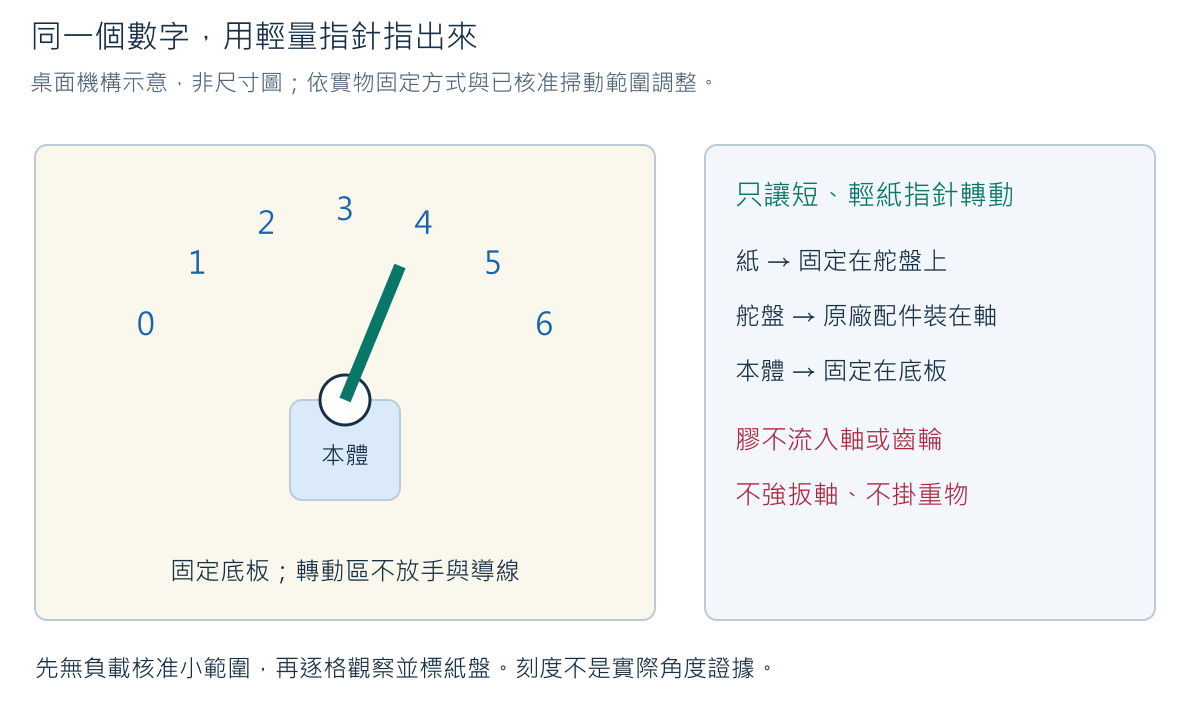

1. 先無負載把舵機指令停在核准0位置，記下軸方向；切電池OFF、拔USB。
2. 依原廠配件方式把合適舵盤裝到輸出軸，再把**短、輕、無尖角**紙指針固定在舵盤上。
   不強扳軸來對刻度，不讓螺絲或膠掉入外殼。黏的是紙與舵盤／固定座，不是軸與本體。
3. 固定舵機本體與底板，保留轉動空間及可按的電源開關；手和導線離開掃動區。
4. 重新依OFF→USB→a→外部ON流程，逐格0、1、2…6。每格觀察穩定後才下一格。
   在紙盤標出實際指向位置，不先用理想角度要求舵機硬對上印好的刻度。
5. 再送4→3，觀察能否回退到相應格。這是後續紅燈扣次數的指示，不是倒轉電池極性。

紙盤可用現有紙材，固定方式依實物安全核准，不增加金屬尖指針或重物。
全部過程包含負載電壓觀察；一人難同時看表、按鍵與看指針時，同組分工，不用手硬壓住舵機。

### 7.4 加上OLED：共用count，不另算一份

切外部電源OFF、取出至少一顆電池、拔USB。沿用Week 5核准OLED接線，
填入其profile、位址、SDA／SCL；`WITH_OLED=true`，確認GPIO互不重複。
目前程式同樣只適用核准SSD1306 128×64 I2C；其他控制器要先換對建構子並驗證。
重新Verify、Upload與逐路斷電核對後，先確認OLED的DISARMED，再依a流程測0、4、3。

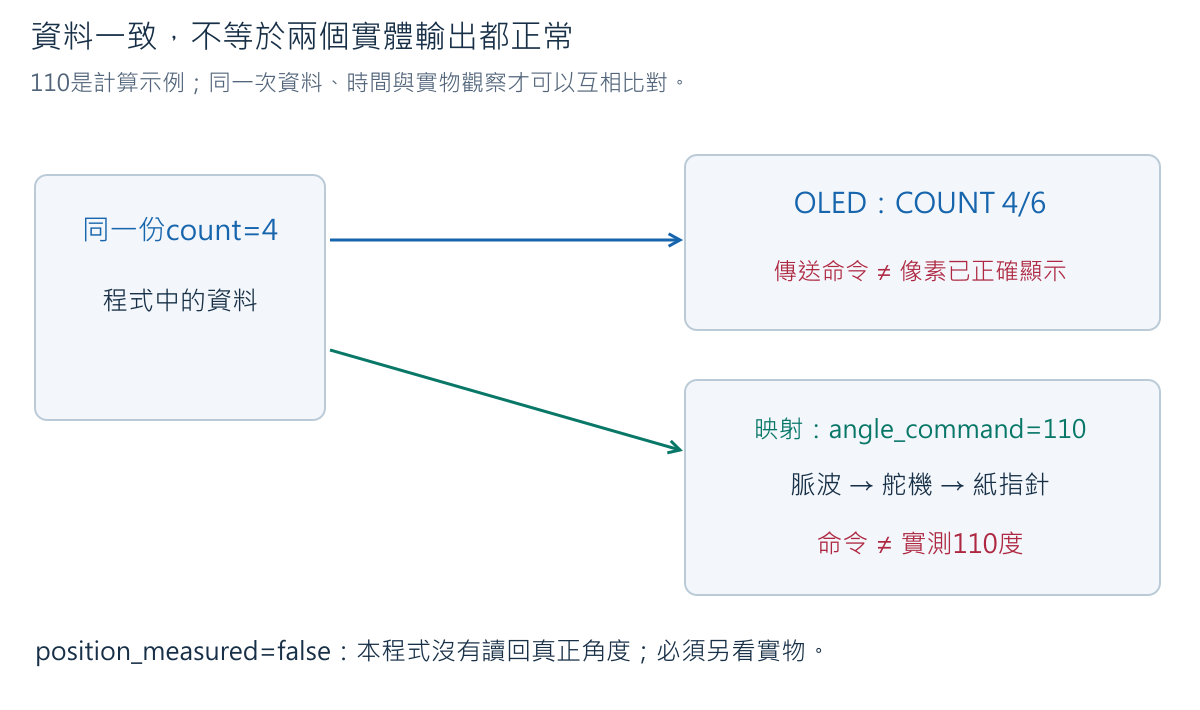

OLED的COUNT 4/6與ANGLE CMD是程式資料，SIGNAL ON表示正在輸出控制脈波，
NO SENSE提醒沒有量到實際角度。指針若仍在3，先中止查證，不能只拍OLED當成功。
改OLED內容不能修正機械卡住；改舵機角度也不能修正錯誤的count變數。

示例log（非實測）：

```text
device_id=BOARD-T01 event_type=pointer_command value=4 unit=count angle_command=110 position_measured=false uptime_ms=8000
device_id=BOARD-T01 event_type=pointer_status state=ARMED value=4 unit=count signal_attached=true position_measured=false power_measured=false reason=operator_arm_power_off_acknowledged uptime_ms=8000
```

`value=4 unit=count`是示例次數；`angle_command=110`單位為指令角度。
`signal_attached=true`表示library控制通道啟用，不能證明電池有電。
`position_measured=false`與`power_measured=false`說明程式沒有這兩種量測。
`uptime_ms`為本次開機後時間，不與上次重啟的log混算。


## 8. 停止、逾時、重啟與故障復原

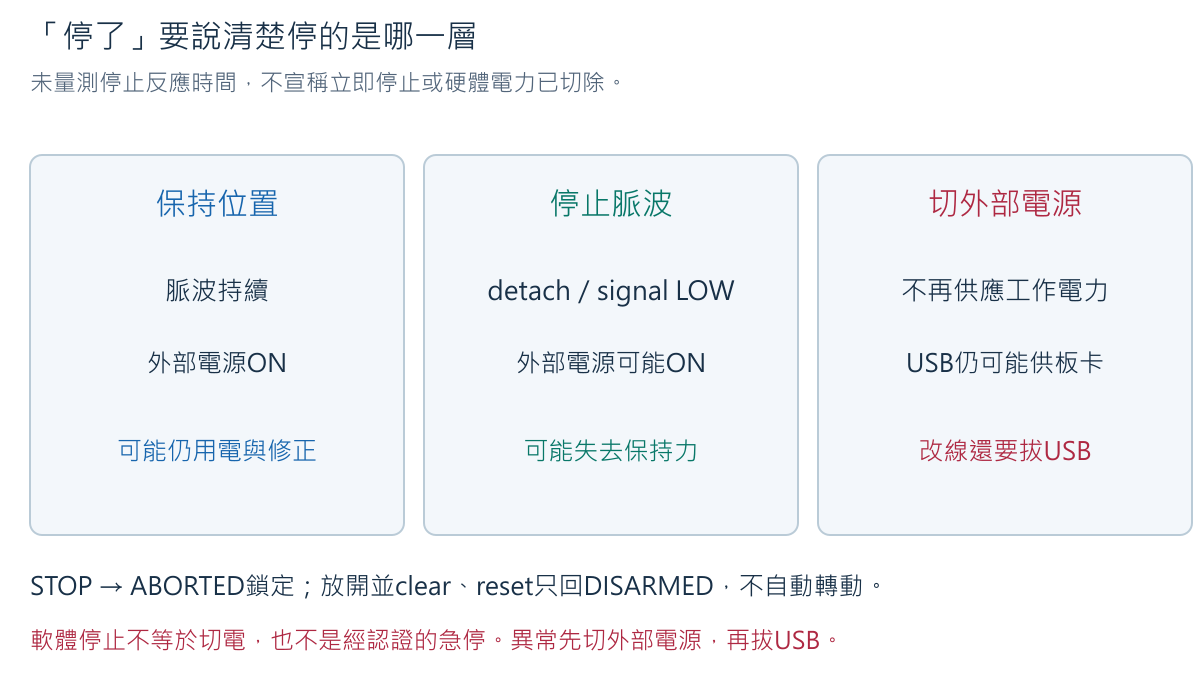

| 做法 | 控制脈波 | 外部電源 | 能說的事／不能說的事 |
|---|---|---|---|
| 保持某角度 | 繼續 | 仍ON | 舵機可能持續修正並用電；不是斷電 |
| q或STOP後detach | 已要求停脈波，訊號LOW | 仍可能ON | 不再送定位指令；實際是否滑動／仍異常須觀察 |
| 電池盒OFF | 依當時程式而定 | 切外部供電 | 切掉舵機工作電力；板子仍可能由USB工作 |
| 外部OFF再拔USB | 停止 | 都斷開 | 才進行改線、拆機構或通斷量測 |

最少完成下列有不同目的的檢查，不把同一張照片重複當四項證據：

1. **停止鍵**：核准輕指針正常動作時按STOP，確認ABORTED，停止脈波命令出現，
   操作人員切外部OFF。按住時c/z/a不得啟用。記下從按下到log及可見反應的最長觀察值與量測方式。
2. **最大啟用時間**：安全靜置在核准位置，超過30秒應arm_session_timeout、detach與鎖定。
   途中發新數字不延長這個期限。不要用卡住的負載等時間到。
3. **軟體故障**：f注入，確認停止；仍ABORTED時a無效。檢查原因、STOP放開後c、z，
   外部電源OFF的狀態下才重新a，再ON。取消注入不是供電已正常的量測證據。
4. **重啟**：先外部OFF再按RST，程式回DISARMED，不自動attach或重播上局動作。
   開機時STOP按住則ABORTED。萬用電表不能證明重啟瞬間完全沒脈波；這一項另列實機限制。

本程式不具自動角度／電壓／過流回饋。不舒服的異味、發熱、抖動、軸碰撞或重啟，
都直接外部OFF再拔USB，不為作業反覆重現。軟件停止機制不取代可接近的電源開關。

## 9. 深入討論（Discussion）：指針不動，是程式、供電還是機構問題？

以下先問「哪一層已有證據」，再決定第一個安全檢查。示例不代表本片舵機測試結果。

### 9.1 程式印了110，就可以換舵機？

**題目**：count變4，Serial有angle_command=110，指針沒動。先判舵機壞掉合理嗎？

**預期答案**：證據不足。先外部OFF、拔USB，核對profile與signal／共地／V+。
已知的是命令，不知道電源是否到位、脈波是否正確、機構是否卡住。
若重新量測需上電，按前述固定測點與順序重新開始，不帶電追線。
沒有示波器時不能宣稱脈波波形合格，只能保留相應待驗項目。

### 9.2 4.8與110，是同一種量嗎？

**題目**：表上4.8 V，log110，能不能說舵機得到110 V？

**預期答案**：不能。4.8 V是指定供電測點的電位差，110是程式指令角度，
角度再由library映射成脈波時間。單位與測點／資料來源不同，不能只比較兩個數字大小。
電表直流檔量signal得到的平均數也不能直接當角度。

### 9.3 無負載能動，加長指針就卡住

**題目**：短指針正常，改很長後抖動。可以提高供電讓它更有力嗎？

**預期答案**：先外部OFF、拔USB，恢復短輕指針、移除碰撞並檢查固定。
較長指針增加力臂與慣性，即使很輕也可能改變負載。不能超出核准電壓嘗試，
也不能用手強推確認它「有沒有力」。只改指針這一項，才能比較結果與原因。

### 9.4 detach後偏掉，是程式算錯？

**題目**：q後從4慢慢偏向3。是否要每100 ms重新attach一次？

**預期答案**：不能這樣補救。停止定位脈波後可能失去保持力，指針平衡、摩擦與重力也會影響。
先對照採用策略與機構，再由教師評估；反覆attach可能產生啟動動作與耗電，沒有解決安全需求。
若要維持顯示，可以保留OLED最後次數並明示指針已停控制，不假稱它一定維持在4。

### 9.5 count=6，卻指在紙盤5

**題目**：前面各格逐漸偏差，最後6指到5。把SIX_ANGLE加20度就好？

**預期答案**：先停機確認紙盤與舵盤起始位置、count映射、供電及碰撞。
只有核准範圍內才可能調整映射／刻度；不能直接越過SAFE_MAX_ANGLE或放大pulse範圍。
如果無精確量角方法，可報告「對應到紙盤第幾格」，不要寫無依據的角度精度。

### 9.6 OLED在4、指針在3，誰有最後決定權？

**題目**：兩個輸出不同步，報告只截OLED可以嗎？

**預期答案**：不可以。先比對同一次count、angle_command與時間，再看signal與實物。
OLED和指針都是輸出，不是誰較好看誰就是真相。要保存不一致證據與修正過程，
若缺電氣或機構證據，結論只能到目前已知層次。


## 10. 故障排查與完成證據

| 症狀 | 第一個安全動作 | 查核方向 |
|---|---|---|
| profile_missing | 保持舵機斷電 | 型號、GPIO、電源與角度／脈寬缺值，不能只改true |
| 指針完全不動 | 外部OFF，再拔USB | 命令是否拒絕、signal、共地、負載電源與機構 |
| 電表負號 | 外部OFF | 紅黑表筆與端子極性；不要直接忽略負號 |
| a被拒絕 | 外部保持OFF | STOP是否按住、是否ABORTED尚未c/z；不反覆RST繞過 |
| 數字命令被拒絕 | 停止連續送命令 | 是否未ARMED、尚不到1秒、已超30秒或STOP仍LOW |
| OLED與指針不同 | 中止並切外部OFF | 同一count資料、位址／映射／供電與實物位置 |
| 抖、熱、卡住、重啟 | 立即外部OFF再拔USB | 交教師確認，不反覆上電收集更多相同錯誤 |

| 個人紀錄 | 必須保存 | 完成判定 |
|---|---|---|
| profile | 實物版本、功能腳序、供電方案與端子、核准脈寬／頻率／角度／GPIO及來源 | 沒證據的項目保持待驗 |
| 電氣 | 空載正負號／V、動作供電V、表檔、兩測點及profile比較 | 不把V當A，不把慢表讀數當瞬間最低值 |
| 指針 | 無負載先驗證、紙指針0～6與4→3、固定照片及命令log | 命令與實物相符，無卡住／過熱等異常 |
| 同步 | OLED與指針同一count，發現差異的處理 | 角度命令與實際角度分開 |
| 停止與復原 | STOP、逾時、f、c/z、RST及斷電順序 | 持續停止不被繞過，不自動續動 |
| 推理 | Discussion六題，明確寫已知／未知／第一安全檢查 | 有根據地排錯，不直接猜器材壞了 |

未進行實機驗證時，以上實物證據欄明寫待驗，不能填入圖中的30／150或5.0／4.4當測試結果。
不需要為不同表格重複做同一無目的實驗；一段有完整條件的證據可交叉引用。

收尾：停止命令後切電池盒OFF、取出電池、拔USB，電表OFF，
先拆外部正極與舵機V+，再拆訊號、低功率供電、最後共同地。確認端子絕緣、紙盤與舵盤分開收納。
帶入Week 7的是核准的設定、實物位置與停止限制，不是「SG90永遠準確」的結論。

## 11. 官方資料與適用界限

- [TowerPro SG90](https://towerpro.com.tw/product/sg90-7/)：原廠產品版本資料，不直接等同手上標同名的模組。
- [Arduino舵機排查](https://support.arduino.cc/hc/en-us/articles/360017053760-Troubleshoot-servo-motors)：控制連線、供電及共同地的排查方向。
- [ESP32Servo官方原始碼](https://github.com/madhephaestus/ESP32Servo)：attach、write、detach及命令換算；本課編譯使用3.2.1。
- [U8g2設定](https://github.com/olikraus/u8g2/wiki/u8g2setupcpp)：沿用Week 5已核准的顯示器設定。

紙指針、0～6映射、30秒限制與討論為本課設計，不冒稱原廠實驗。
文件、編譯、主機stub邏輯、指定板卡實機及負載測試是不同驗證層次。
